# IQM fine-tuning experiment (SPSA)

This notebook supports a simple **hypothesis**:

> **Weights trained only with a noiseless `StatevectorEstimator` are not optimal for IQM shot-based readout.**  
> **SPSA fine-tuning on the real IQM objective** can **improve full-test IQM metrics** vs those same SV-trained weights.

**Protocol**

1. **Phase A — Strong SV baseline:** **Adam + parameter-shift gradients** on MSE (same recipe as `models/model_odra.ipynb`), on the **fit** subset of training data. Optionally **load** `models/quantum_best_weights_2.pth` if present. This targets **~80–85%** statevector test accuracy so later phases are worth analyzing.
2. **Phase B — IQM test (before):** Repeated full-test jobs on IQM → mean ± std; confusion from averaged ⟨Z⟩.
3. **Phase C — IQM fine-tuning:** SPSA with IQM shot MSE; validation + early stopping.
4. **Phase D — IQM test (after):** Same repeated evaluation and comparison.

**Controls**

- `SMOKE_TEST = True`: no IQM; proxy metrics only.
- **Security:** `IQM_TOKEN` via environment variable; clear outputs before sharing.

## Configuration

In [60]:
import os
from pathlib import Path


def find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for cand in [p, *p.parents]:
        if (cand / "pyproject.toml").exists():
            return cand
    return p


REPO_ROOT = find_repo_root()

SMOKE_TEST = False

IQM_URL = os.environ.get("IQM_SERVER_URL", "https://odra5.e-science.pl/")
IQM_TOKEN = os.environ.get("IQM_TOKEN")

NUM_QUBITS = 5
ANSATZ_DEPTH = 2
RANDOM_SEED = 42

SHOTS = 1024 if not SMOKE_TEST else None

IQM_TEST_REPEATS = 5
VAL_EVAL_REPEATS = 3
VAL_FRACTION = 0.15

# --- Phase A: Adam on StatevectorEstimator (matches model_odra.ipynb) ---
# If this file exists (train `model_odra.ipynb` once, or copy weights here), load `quantum_layer` weights and skip full training unless refining.
SV_WEIGHTS_PTH = REPO_ROOT / "models" / "quantum_best_weights_2.pth"
SV_ADAM_EPOCHS = 30
SV_ADAM_LR = 0.01
SV_ADAM_BATCH_SIZE = 16
# After a successful load, optionally train this many extra epochs on X_train_fit (0 = use checkpoint as-is).
SV_ADAM_REFINE_EPOCHS = 0

# --- Phase C: IQM SPSA fine-tuning ---
IQM_FT_MAX_OUTER_EPOCHS = 24
IQM_FT_MINIBATCHES_PER_EPOCH = 6
IQM_FT_MINIBATCH_SIZE = 48
IQM_FT_SPSA_MAXITER = 10
IQM_FT_SPSA_LEARNING_RATE = 0.08
IQM_FT_SPSA_PERTURBATION = 0.05
IQM_FT_SPSA_RESAMPLINGS = 2
IQM_FT_SPSA_SECOND_ORDER = False

EARLY_STOP_PATIENCE = 5
EARLY_STOP_MIN_DELTA = 0.005
EARLY_STOP_MONITOR = "f1_macro"

TEST_EVAL_CHUNK = None

# Retry TLS/connection drops while polling IQM job status (SSLEOFError, etc.)
IQM_HTTP_MAX_RETRIES = 12
IQM_HTTP_RETRY_BASE_SEC = 2.0

WEIGHTS_SV = REPO_ROOT / "tests" / "model_odra_iqm_exp_weights_sv.npy"
WEIGHTS_FINAL = REPO_ROOT / "tests" / "model_odra_iqm_exp_weights_after_iqm_ft.npy"


## Imports

In [ ]:
import random
import time

import requests
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from ucimlrepo import fetch_ucirepo

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorEstimator, PrimitiveResult, PubResult
from qiskit.primitives.base import BaseEstimatorV2
from qiskit.primitives.containers.data_bin import DataBin
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.gradients import ParamShiftEstimatorGradient
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_algorithms.optimizers import SPSA
from qiskit_algorithms.utils import algorithm_globals

from iqm.qiskit_iqm import IQMProvider

def robust_iqm_job_result(job, desc: str = "IQM job"):
    """Call job.result() with retries on transient HTTPS/TLS failures during long polls."""
    max_r = int(IQM_HTTP_MAX_RETRIES)
    base = float(IQM_HTTP_RETRY_BASE_SEC)
    for attempt in range(1, max_r + 1):
        try:
            return job.result()
        except (
            requests.exceptions.SSLError,
            requests.exceptions.ConnectionError,
            requests.exceptions.Timeout,
            requests.exceptions.ChunkedEncodingError,
            OSError,
        ) as e:
            if attempt == max_r:
                raise
            wait = base * (2 ** (attempt - 1))
            msg = str(e).replace("\n", " ")[:160]
            print(
                f"  {desc}: transient {type(e).__name__} ({msg}) — "
                f"sleep {wait:.1f}s, retry {attempt}/{max_r}"
            )
            time.sleep(wait)
    raise RuntimeError("robust_iqm_job_result: unreachable")



## Data and circuits (same as `models/model_odra.ipynb`)

In [53]:
def set_random_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    algorithm_globals.random_seed = seed


set_random_seed(RANDOM_SEED)


def prepare_data(test_size: float = 0.2, random_state: int = 42):
    banknote_authentication = fetch_ucirepo(id=267)
    X = banknote_authentication.data.features.to_numpy()
    y = banknote_authentication.data.targets.to_numpy().ravel()

    assert X.shape[1] == 4
    assert set(np.unique(y)) == {0, 1}

    variance = X[:, 0].reshape(-1, 1)
    skewness = X[:, 1].reshape(-1, 1)
    interaction = variance * skewness
    X_expanded = np.hstack((X, interaction))

    X_train, X_test, y_train, y_test = train_test_split(
        X_expanded, y, test_size=test_size, random_state=random_state
    )

    scaler = MinMaxScaler(feature_range=(-np.pi / 4, np.pi / 4))
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test


def ansatz(n_qubits, depth):
    params_per_iter = 4 * n_qubits
    theta = ParameterVector("θ", params_per_iter * (depth // 2))
    qc = QuantumCircuit(n_qubits)
    for j in range(depth // 2):
        offset = j * params_per_iter
        for i in range(n_qubits):
            qc.ry(theta[offset + i], i)
        for i in range(n_qubits):
            control, target = i, (i + 1) % n_qubits
            param_idx = offset + n_qubits + i
            qc.rz(theta[param_idx], target)
            qc.cz(control, target)
        offset_l2 = offset + 2 * n_qubits
        for i in range(n_qubits):
            qc.rx(theta[offset_l2 + i], i)
        for i in range(n_qubits):
            control, target = i, (i - 1) % n_qubits
            param_idx = offset_l2 + n_qubits + i
            qc.ry(theta[param_idx], target)
            qc.cz(control, target)
    return qc


def create_angle_encoding(num_qubits: int) -> QuantumCircuit:
    qc_data = QuantumCircuit(num_qubits)
    input_params = ParameterVector("x", num_qubits)
    for i in range(num_qubits):
        qc_data.ry(input_params[i], i)
    return qc_data


class SimpleIQMJob:
    def __init__(self, result):
        self._result = result

    def result(self):
        return self._result


class IQMBackendEstimator(BaseEstimatorV2):
    '''Z readout on qubit 0 from measured bitstrings (same as `model_odra.ipynb`).'''

    def __init__(self, backend, options=None):
        super().__init__()
        self._backend = backend
        self._options = options or {"shots": 100}

    def run(self, pubs, precision=None):
        if not isinstance(pubs, list):
            pubs = [pubs]
        job_results = []

        base_circuit = pubs[0][0]
        circuit_with_meas = base_circuit.copy()
        if circuit_with_meas.num_clbits == 0:
            circuit_with_meas.measure_all()

        transpiled_qc = transpile(circuit_with_meas, self._backend, optimization_level=0)

        for pub in pubs:
            _, _obs, parameter_values = pub
            if parameter_values.ndim == 1:
                parameter_values = [parameter_values]

            pub_expectations = []
            for params in parameter_values:
                bound_qc = transpiled_qc.assign_parameters(params)
                try:
                    job = self._backend.run(bound_qc, shots=self._options["shots"])
                    result = robust_iqm_job_result(job, desc="IQMBackendEstimator")
                    counts = result.get_counts()
                    if isinstance(counts, list):
                        counts = counts[0]
                    shots = sum(counts.values())
                    count_0 = sum(c for bitstring, c in counts.items() if bitstring[-1] == "0")
                    p0 = count_0 / shots
                    pub_expectations.append(2 * p0 - 1)
                except Exception as e:
                    print(f"Job failed: {e}")
                    pub_expectations.append(0.0)

            data = DataBin(evs=np.array(pub_expectations), shape=(len(pub_expectations),))
            job_results.append(PubResult(data=data))

        return SimpleIQMJob(PrimitiveResult(job_results))


## Build circuit, `qnn_sv`, and IQM backend

In [54]:
hw_feature_map = create_angle_encoding(NUM_QUBITS)
hw_ansatz = ansatz(NUM_QUBITS, ANSATZ_DEPTH)

hw_qc = QuantumCircuit(NUM_QUBITS)
hw_qc.compose(hw_feature_map, qubits=range(NUM_QUBITS), inplace=True)
hw_qc.compose(hw_ansatz, inplace=True)

observable = SparsePauliOp.from_list([("I" * (NUM_QUBITS - 1) + "Z", 1)])

_sv_estimator = StatevectorEstimator()
_sv_gradient = ParamShiftEstimatorGradient(estimator=_sv_estimator)

qnn_sv = EstimatorQNN(
    circuit=hw_qc,
    observables=observable,
    input_params=list(hw_feature_map.parameters),
    weight_params=list(hw_ansatz.parameters),
    estimator=_sv_estimator,
    gradient=_sv_gradient,
)

SESSION_T_UTC = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
print("Notebook session timestamp (protocol hygiene):", SESSION_T_UTC)

iqm_backend = None
if SMOKE_TEST:
    print("SMOKE_TEST=True: skipping IQM provider; IQM phases will use statevector proxy.")
else:
    token = IQM_TOKEN or input("Enter IQM Token: ")
    provider = IQMProvider(IQM_URL, token=token)
    iqm_backend = provider.get_backend()
    print(f"Connected to backend: {iqm_backend.name} at {SESSION_T_UTC}")

hw_qc_measured = hw_qc.copy()
if hw_qc_measured.num_clbits == 0:
    hw_qc_measured.measure_all()

iqm_transpiled_template = None
if iqm_backend is not None:
    iqm_transpiled_template = transpile(hw_qc_measured, iqm_backend, optimization_level=0)

print("num_weights:", qnn_sv.num_weights)


Notebook session timestamp (protocol hygiene): 2026-03-22 14:59:33 UTC


Enter IQM Token:  KvDiuC2eiW1bHgf1HnBHWLxNpVolTbokv7ZECPmMtbgBnRYPEsB9cJut4by0rPTY


Connected to backend: IQMBackend at 2026-03-22 14:59:33 UTC
num_weights: 20


## Helpers: forward, batched IQM dataset eval, SPSA phase

In [55]:
X_train, X_test, y_train_raw, y_test_raw = prepare_data(
    test_size=0.2, random_state=RANDOM_SEED
)
y_train = (2 * y_train_raw - 1).astype(np.float64)
y_test = (2 * y_test_raw - 1).astype(np.float64)

# Fit pool vs IQM validation (from training only; test never touched during tuning)
_strat = (y_train > 0).astype(np.int32)
X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=VAL_FRACTION,
    random_state=RANDOM_SEED + 7,
    stratify=_strat,
)
print(
    f"Data: train_fit={len(X_train_fit)} val={len(X_val)} test={len(X_test)} "
    f"(VAL_FRACTION={VAL_FRACTION})"
)


def predict_raw_sv(theta: np.ndarray, X: np.ndarray) -> np.ndarray:
    theta = np.asarray(theta, dtype=float).ravel()
    out = []
    for i in range(X.shape[0]):
        v = qnn_sv.forward(X[i : i + 1], theta)
        out.append(float(np.asarray(v, dtype=float).ravel()[0]))
    return np.asarray(out, dtype=float)


def metrics_from_preds(preds: np.ndarray, y: np.ndarray) -> dict:
    y = np.asarray(y, dtype=float).ravel()
    cls_pred = np.where(preds > 0, 1, -1)
    return {
        "loss": float(np.mean((preds - y) ** 2)),
        "acc": float(accuracy_score(y, cls_pred)),
        "f1": float(f1_score(y, cls_pred, pos_label=1)),
        "f1_macro": float(
            f1_score(y, cls_pred, labels=[-1, 1], average="macro", zero_division=0)
        ),
        "cls_pred": cls_pred,
        "preds": preds,
    }


def _z0_expectation_from_counts(counts: dict) -> float:
    shots = sum(counts.values())
    if shots == 0:
        return 0.0
    count_0 = sum(c for bitstring, c in counts.items() if bitstring[-1] == "0")
    return float(2 * count_0 / shots - 1)


def _normalize_counts_list(result) -> list[dict]:
    raw = result.get_counts()
    if isinstance(raw, dict):
        return [raw]
    return list(raw)


def _evaluate_iqm_single_pass(
    weights: np.ndarray,
    X_arr: np.ndarray,
    y_arr: np.ndarray,
    label: str,
) -> dict:
    '''One full pass over X_arr on IQM (or SV proxy).'''
    w = np.asarray(weights, dtype=float).ravel()
    if SMOKE_TEST or iqm_transpiled_template is None:
        preds = predict_raw_sv(w, X_arr)
        m = metrics_from_preds(preds, y_arr)
        m["note"] = "proxy: StatevectorEstimator"
        return m

    n = X_arr.shape[0]
    chunk = TEST_EVAL_CHUNK if TEST_EVAL_CHUNK is not None else n
    all_counts: list[dict] = []
    for start in range(0, n, chunk):
        stop = min(start + chunk, n)
        bound = []
        for i in range(start, stop):
            vals = np.concatenate([X_arr[i], w])
            bound.append(iqm_transpiled_template.assign_parameters(vals))
        print(f"  {label}: circuits {start}..{stop - 1} ({len(bound)}), shots={SHOTS}")
        job = iqm_backend.run(bound, shots=int(SHOTS))
        res = robust_iqm_job_result(job, desc=f"{label} chunk")
        all_counts.extend(_normalize_counts_list(res))

    preds = np.array([_z0_expectation_from_counts(c) for c in all_counts], dtype=float)
    m = metrics_from_preds(preds, y_arr)
    m["note"] = "IQM hardware"
    return m


def evaluate_iqm_repeated(
    weights: np.ndarray,
    X_arr: np.ndarray,
    y_arr: np.ndarray,
    label: str,
    n_repeats: int,
) -> dict:
    '''n_repeats independent full evaluations; report mean±std; confusion from mean ⟨Z⟩.'''
    y_arr = np.asarray(y_arr, dtype=float)
    losses, accs, f1s, f1ms = [], [], [], []
    pred_stack = []

    for r in range(n_repeats):
        m = _evaluate_iqm_single_pass(
            weights, X_arr, y_arr, f"{label} repeat {r + 1}/{n_repeats}"
        )
        losses.append(m["loss"])
        accs.append(m["acc"])
        f1s.append(m["f1"])
        f1ms.append(m["f1_macro"])
        pred_stack.append(m["preds"])
        print(
            f"    -> loss={m['loss']:.6f} acc={m['acc']:.4f} f1={m['f1']:.4f} "
            f"f1_macro={m['f1_macro']:.4f} [{m['note']}]"
        )

    pred_mean = np.mean(np.stack(pred_stack, axis=0), axis=0)
    agg = metrics_from_preds(pred_mean, y_arr)
    out = {
        "loss_mean": float(np.mean(losses)),
        "loss_std": float(np.std(losses, ddof=1)) if len(losses) > 1 else 0.0,
        "acc_mean": float(np.mean(accs)),
        "acc_std": float(np.std(accs, ddof=1)) if len(accs) > 1 else 0.0,
        "f1_mean": float(np.mean(f1s)),
        "f1_std": float(np.std(f1s, ddof=1)) if len(f1s) > 1 else 0.0,
        "f1_macro_mean": float(np.mean(f1ms)),
        "f1_macro_std": float(np.std(f1ms, ddof=1)) if len(f1ms) > 1 else 0.0,
        "cls_pred": agg["cls_pred"],
        "preds": pred_mean,
    }
    # expose scalar keys compatible with older summary table
    out["loss"] = out["loss_mean"]
    out["acc"] = out["acc_mean"]
    out["f1"] = out["f1_mean"]
    out["f1_macro"] = out["f1_macro_mean"]
    if SMOKE_TEST or iqm_transpiled_template is None:
        out["note"] = "proxy: StatevectorEstimator (repeated runs identical)"
    else:
        out["note"] = f"IQM hardware ({n_repeats} repeats)"

    print(
        f"{label} AGG mean±std: loss={out['loss_mean']:.6f}±{out['loss_std']:.6f} "
        f"acc={out['acc_mean']:.4f}±{out['acc_std']:.4f} f1={out['f1_mean']:.4f}±{out['f1_std']:.4f} "
        f"f1_macro={out['f1_macro_mean']:.4f}±{out['f1_macro_std']:.4f}"
    )
    return out


def mse_minibatch_statevector(theta: np.ndarray, X: np.ndarray, y: np.ndarray) -> float:
    preds = predict_raw_sv(theta, X)
    return float(np.mean((preds - y) ** 2))


def mse_minibatch_iqm(theta: np.ndarray, X: np.ndarray, y: np.ndarray) -> float:
    if SMOKE_TEST:
        return mse_minibatch_statevector(theta, X, y)
    w = np.asarray(theta, dtype=float).ravel()
    bound = []
    for i in range(X.shape[0]):
        vals = np.concatenate([X[i], w])
        bound.append(iqm_transpiled_template.assign_parameters(vals))
    job = iqm_backend.run(bound, shots=int(SHOTS))
    res = robust_iqm_job_result(job, desc="IQM minibatch MSE")
    counts_list = _normalize_counts_list(res)
    preds = np.array([_z0_expectation_from_counts(c) for c in counts_list], dtype=float)
    yv = np.asarray(y, dtype=float).ravel()
    return float(np.mean((preds - yv) ** 2))


def run_spsa_phase(
    weights_init: np.ndarray,
    rng: np.random.Generator,
    train_mode: str,
    n_outer_epochs: int,
    minibatches_per_epoch: int,
    minibatch_size: int,
    spsa_maxiter: int,
    lr: float,
    pert: float,
    phase_name: str,
    X_pool: np.ndarray,
    y_pool: np.ndarray,
    resamplings: int = 1,
    second_order: bool = False,
) -> np.ndarray:
    assert train_mode in ("statevector", "iqm")
    weights = np.asarray(weights_init, dtype=float).ravel().copy()
    loss_fn = mse_minibatch_statevector if train_mode == "statevector" else mse_minibatch_iqm

    for ep in range(n_outer_epochs):
        for mb in range(minibatches_per_epoch):
            idx = rng.choice(
                X_pool.shape[0],
                size=min(minibatch_size, X_pool.shape[0]),
                replace=False,
            )
            Xb = X_pool[idx]
            yb = y_pool[idx]
            tag = f"{phase_name} | outer {ep + 1}/{n_outer_epochs} mb {mb + 1}/{minibatches_per_epoch} ({train_mode})"

            def objective(theta):
                return loss_fn(theta, Xb, yb)

            step = {"k": 0}

            def cb(nfev, parameters, value, stepsize, accepted):
                step["k"] += 1
                lv = float(np.asarray(value, dtype=float).ravel()[0])
                print(f"  {tag} SPSA {step['k']}/{spsa_maxiter}: loss={lv:.6f} nfev={nfev}")

            opt = SPSA(
                maxiter=spsa_maxiter,
                learning_rate=lr,
                perturbation=pert,
                resamplings=resamplings,
                second_order=second_order,
                callback=cb,
            )
            r = opt.minimize(objective, weights)
            weights = np.asarray(r.x, dtype=float).ravel()
            print(f"  {tag} done nit={r.nit} nfev={r.nfev}")

    return weights


def run_iqm_finetune_early_stop(
    weights_init: np.ndarray,
    rng: np.random.Generator,
) -> tuple[np.ndarray, dict]:
    '''Phase C with IQM validation and patience-based early stopping.'''
    weights = np.asarray(weights_init, dtype=float).ravel().copy()
    best_w = weights.copy()
    best_score = -1.0
    patience_left = EARLY_STOP_PATIENCE
    history = []

    for ep in range(IQM_FT_MAX_OUTER_EPOCHS):
        tag_prefix = f"Phase C (IQM FT) outer {ep + 1}/{IQM_FT_MAX_OUTER_EPOCHS}"
        print(f"\n=== {tag_prefix} ===")

        for mb in range(IQM_FT_MINIBATCHES_PER_EPOCH):
            idx = rng.choice(
                X_train_fit.shape[0],
                size=min(IQM_FT_MINIBATCH_SIZE, X_train_fit.shape[0]),
                replace=False,
            )
            Xb = X_train_fit[idx]
            yb = y_train_fit[idx]
            tag = f"{tag_prefix} mb {mb + 1}/{IQM_FT_MINIBATCHES_PER_EPOCH}"

            def objective(theta):
                return mse_minibatch_iqm(theta, Xb, yb)

            step = {"k": 0}

            def cb(nfev, parameters, value, stepsize, accepted):
                step["k"] += 1
                lv = float(np.asarray(value, dtype=float).ravel()[0])
                print(f"  {tag} SPSA {step['k']}/{IQM_FT_SPSA_MAXITER}: loss={lv:.6f} nfev={nfev}")

            opt = SPSA(
                maxiter=IQM_FT_SPSA_MAXITER,
                learning_rate=IQM_FT_SPSA_LEARNING_RATE,
                perturbation=IQM_FT_SPSA_PERTURBATION,
                resamplings=IQM_FT_SPSA_RESAMPLINGS,
                second_order=IQM_FT_SPSA_SECOND_ORDER,
                callback=cb,
            )
            r = opt.minimize(objective, weights)
            weights = np.asarray(r.x, dtype=float).ravel()
            print(f"  {tag} done nit={r.nit} nfev={r.nfev}")

        val = evaluate_iqm_repeated(
            weights,
            X_val,
            y_val,
            f"{tag_prefix} IQM val",
            n_repeats=VAL_EVAL_REPEATS,
        )
        if EARLY_STOP_MONITOR == "acc":
            score = val["acc_mean"]
        else:
            score = val["f1_macro_mean"]

        history.append({"epoch": ep + 1, "val_acc": val["acc_mean"], "val_f1_macro": val["f1_macro_mean"]})

        improved = score > best_score + EARLY_STOP_MIN_DELTA
        if improved:
            best_score = score
            best_w = weights.copy()
            patience_left = EARLY_STOP_PATIENCE
            print(f"  Early-stop: new best {EARLY_STOP_MONITOR}={score:.6f} (saved weights)")
        else:
            patience_left -= 1
            print(
                f"  Early-stop: no improvement ({EARLY_STOP_MONITOR}={score:.6f} vs best {best_score:.6f}), "
                f"patience {patience_left}/{EARLY_STOP_PATIENCE}"
            )

        if patience_left <= 0:
            print("Early stopping Phase C.")
            break

    return best_w, {"best_score": best_score, "monitor": EARLY_STOP_MONITOR, "history": history}



Data: train_fit=932 val=165 test=275 (VAL_FRACTION=0.15)


## Phase A — **Adam** on `StatevectorEstimator` (strong baseline, same recipe as `model_odra.ipynb`)

In [56]:
rng = np.random.default_rng(RANDOM_SEED)


class QuantumAdamNet(nn.Module):
    '''Thin wrapper so we can load `HybridModel` checkpoints (`quantum_layer.*`).'''

    def __init__(self, qnn: EstimatorQNN):
        super().__init__()
        self.connector = TorchConnector(qnn)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.connector(x)


def _load_torch_checkpoint_into_connector(connector: TorchConnector, path: Path) -> bool:
    if not path.is_file():
        return False
    try:
        blob = torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        blob = torch.load(path, map_location="cpu")
    if not isinstance(blob, dict):
        return False
    w = None
    if "quantum_layer.weight" in blob:
        w = blob["quantum_layer.weight"]
    elif "weight" in blob:
        w = blob["weight"]
    if w is None:
        return False
    if int(w.numel()) != int(connector.neural_network.num_weights):
        print(
            f"Checkpoint ignored: weight elements {w.numel()} != qnn num_weights "
            f"{connector.neural_network.num_weights}"
        )
        return False
    connector.load_state_dict({"weight": w})
    return True


def _sv_test_accuracy(net: QuantumAdamNet) -> float:
    net.eval()
    with torch.no_grad():
        out = net(torch.tensor(X_test, dtype=torch.float32))
        pred = torch.where(out.reshape(-1) > 0, 1.0, -1.0)
        y_t = torch.tensor(y_test, dtype=torch.float32).reshape(-1)
        return float((pred == y_t).float().mean().item())


q_adam = QuantumAdamNet(qnn_sv)
loaded = _load_torch_checkpoint_into_connector(q_adam.connector, SV_WEIGHTS_PTH)

train_epochs = 0
if loaded and SV_ADAM_REFINE_EPOCHS > 0:
    train_epochs = SV_ADAM_REFINE_EPOCHS
    print(
        f"Phase A: loaded {SV_WEIGHTS_PTH.name}, refining {SV_ADAM_REFINE_EPOCHS} epoch(s) on train_fit"
    )
elif loaded:
    train_epochs = 0
    print(f"Phase A: loaded strong baseline from {SV_WEIGHTS_PTH} (skip Adam; set SV_ADAM_REFINE_EPOCHS>0 to refine)")
elif SV_ADAM_EPOCHS > 0:
    train_epochs = SV_ADAM_EPOCHS
    print(f"Phase A: training Adam {SV_ADAM_EPOCHS} epochs (no checkpoint at {SV_WEIGHTS_PTH})")
else:
    raise ValueError("No checkpoint and SV_ADAM_EPOCHS==0 — nothing to do in Phase A")

if train_epochs > 0:
    opt = torch.optim.Adam(q_adam.parameters(), lr=SV_ADAM_LR)
    Xf = torch.tensor(X_train_fit, dtype=torch.float32)
    yf = torch.tensor(y_train_fit, dtype=torch.float32).reshape(-1, 1)
    loader = DataLoader(
        TensorDataset(Xf, yf),
        batch_size=SV_ADAM_BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(int(RANDOM_SEED)),
    )
    q_adam.train()
    log_every = max(1, train_epochs // 6)
    for ep in range(train_epochs):
        losses = []
        for xb, yb in loader:
            opt.zero_grad(set_to_none=True)
            out = q_adam(xb)
            loss = nn.functional.mse_loss(out.reshape_as(yb), yb)
            loss.backward()
            opt.step()
            losses.append(float(loss.detach()))
        if (ep + 1) % log_every == 0 or ep == 0:
            acc = _sv_test_accuracy(q_adam)
            print(
                f"  Phase A Adam epoch {ep + 1}/{train_epochs} train_mse~{float(np.mean(losses)):.4f} "
                f"statevector_test_acc={acc:.4f}"
            )

weights_sv = q_adam.connector.weight.detach().cpu().numpy().astype(np.float64).ravel()
np.save(WEIGHTS_SV, weights_sv)
print("Saved statevector-trained weights to", WEIGHTS_SV)

metrics_sv_test_exact = metrics_from_preds(predict_raw_sv(weights_sv, X_test), y_test)
print(
    "Statevector snapshot on test (exact): "
    f"loss={metrics_sv_test_exact['loss']:.6f} acc={metrics_sv_test_exact['acc']:.4f} "
    f"f1={metrics_sv_test_exact['f1']:.4f} f1_macro={metrics_sv_test_exact['f1_macro']:.4f}"
)


Phase A: training Adam 30 epochs (no checkpoint at /Users/jkw/Documents/uni/axion/QC1/models/quantum_best_weights_2.pth)
  Phase A Adam epoch 1/30 train_mse~1.2724 statevector_test_acc=0.6473
  Phase A Adam epoch 5/30 train_mse~0.6561 statevector_test_acc=0.8145
  Phase A Adam epoch 10/30 train_mse~0.6233 statevector_test_acc=0.7891
  Phase A Adam epoch 15/30 train_mse~0.5851 statevector_test_acc=0.8036
  Phase A Adam epoch 20/30 train_mse~0.5734 statevector_test_acc=0.8109
  Phase A Adam epoch 25/30 train_mse~0.5695 statevector_test_acc=0.8327
  Phase A Adam epoch 30/30 train_mse~0.5662 statevector_test_acc=0.8364
Saved statevector-trained weights to /Users/jkw/Documents/uni/axion/QC1/tests/model_odra_iqm_exp_weights_sv.npy
Statevector snapshot on test (exact): loss=0.608443 acc=0.8255 f1=0.7818 f1_macro=0.8182


## Phase B — IQM test metrics **before** IQM fine-tuning (same weights as Phase A)

In [ ]:
print(f"Phase B starting at {SESSION_T_UTC} (see build cell for live connect time)")
metrics_iqm_before = evaluate_iqm_repeated(
    weights_sv,
    X_test,
    y_test,
    "Phase B — IQM test BEFORE fine-tune",
    n_repeats=IQM_TEST_REPEATS,
)



Phase B starting at 2026-03-22 14:45:27 UTC (see build cell for live connect time)
    -> loss=0.608791 acc=0.8255 f1=0.7818 f1_macro=0.8182 [proxy: StatevectorEstimator]
    -> loss=0.610472 acc=0.8364 f1=0.7982 f1_macro=0.8303 [proxy: StatevectorEstimator]
    -> loss=0.610713 acc=0.8291 f1=0.7892 f1_macro=0.8228 [proxy: StatevectorEstimator]
    -> loss=0.608417 acc=0.8255 f1=0.7818 f1_macro=0.8182 [proxy: StatevectorEstimator]
    -> loss=0.611330 acc=0.8255 f1=0.7818 f1_macro=0.8182 [proxy: StatevectorEstimator]
Phase B — IQM test BEFORE fine-tune AGG mean±std: loss=0.609945±0.001270 acc=0.8284±0.0047 f1=0.7866±0.0073 f1_macro=0.8215±0.0053


## Phase C — SPSA fine-tuning with **IQM minibatch MSE** (starts from `weights_sv`)

In [61]:
if SMOKE_TEST:
    print("SMOKE_TEST: skipping true IQM fine-tune; keeping Phase A weights as final.")
    weights_after = weights_sv.copy()
    ft_meta = {"note": "smoke: no IQM fine-tune"}
else:
    weights_after, ft_meta = run_iqm_finetune_early_stop(weights_sv, rng)

np.save(WEIGHTS_FINAL, weights_after)
print("Saved final weights to", WEIGHTS_FINAL)
print("Phase C meta:", ft_meta)



=== Phase C (IQM FT) outer 1/24 ===
  Phase C (IQM FT) outer 1/24 mb 1/6 SPSA 1/10: loss=0.663454 nfev=5
  Phase C (IQM FT) outer 1/24 mb 1/6 SPSA 2/10: loss=0.676533 nfev=10
  Phase C (IQM FT) outer 1/24 mb 1/6 SPSA 3/10: loss=0.638996 nfev=15
  Phase C (IQM FT) outer 1/24 mb 1/6 SPSA 4/10: loss=0.624107 nfev=20
  Phase C (IQM FT) outer 1/24 mb 1/6 SPSA 5/10: loss=0.711073 nfev=25
  Phase C (IQM FT) outer 1/24 mb 1/6 SPSA 6/10: loss=0.623239 nfev=30


Progress in queue:   0%|                                                                                                                                                          | 0/1 [00:21<?, ?it/s]


  Phase C (IQM FT) outer 1/24 mb 1/6 SPSA 7/10: loss=0.664897 nfev=35
  Phase C (IQM FT) outer 1/24 mb 1/6 SPSA 8/10: loss=0.759073 nfev=40
  Phase C (IQM FT) outer 1/24 mb 1/6 SPSA 9/10: loss=0.639428 nfev=45
  Phase C (IQM FT) outer 1/24 mb 1/6 SPSA 10/10: loss=0.622817 nfev=50
  Phase C (IQM FT) outer 1/24 mb 1/6 done nit=10 nfev=50


Progress in queue:   0%|                                                                                                                                                          | 0/1 [00:22<?, ?it/s]


  Phase C (IQM FT) outer 1/24 mb 2/6 SPSA 1/10: loss=0.671908 nfev=5
  Phase C (IQM FT) outer 1/24 mb 2/6 SPSA 2/10: loss=0.687573 nfev=10
  Phase C (IQM FT) outer 1/24 mb 2/6 SPSA 3/10: loss=0.670532 nfev=15
  Phase C (IQM FT) outer 1/24 mb 2/6 SPSA 4/10: loss=0.647045 nfev=20


Progress in queue:   0%|                                                                                                                                                          | 0/1 [00:21<?, ?it/s]


  Phase C (IQM FT) outer 1/24 mb 2/6 SPSA 5/10: loss=0.663868 nfev=25
  Phase C (IQM FT) outer 1/24 mb 2/6 SPSA 6/10: loss=0.665769 nfev=30
  Phase C (IQM FT) outer 1/24 mb 2/6 SPSA 7/10: loss=0.651194 nfev=35
  Phase C (IQM FT) outer 1/24 mb 2/6 SPSA 8/10: loss=0.634858 nfev=40
  Phase C (IQM FT) outer 1/24 mb 2/6 SPSA 9/10: loss=0.662600 nfev=45
  Phase C (IQM FT) outer 1/24 mb 2/6 SPSA 10/10: loss=0.666094 nfev=50
  Phase C (IQM FT) outer 1/24 mb 2/6 done nit=10 nfev=50
  Phase C (IQM FT) outer 1/24 mb 3/6 SPSA 1/10: loss=0.687141 nfev=5
  Phase C (IQM FT) outer 1/24 mb 3/6 SPSA 2/10: loss=0.647752 nfev=10


Progress in queue:   0%|                                                                                                                                                          | 0/1 [00:22<?, ?it/s]


  Phase C (IQM FT) outer 1/24 mb 3/6 SPSA 3/10: loss=0.646139 nfev=15


SSLError: HTTPSConnectionPool(host='odra5.e-science.pl', port=443): Max retries exceeded with url: /api/v1/jobs/019d1652-31db-7bf2-aa5d-96fc42714d29 (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1010)')))

## Phase D — IQM test metrics **after** fine-tuning + comparison

    -> loss=0.610177 acc=0.8255 f1=0.7818 f1_macro=0.8182 [proxy: StatevectorEstimator]
    -> loss=0.608660 acc=0.8364 f1=0.7982 f1_macro=0.8303 [proxy: StatevectorEstimator]
    -> loss=0.609625 acc=0.8291 f1=0.7873 f1_macro=0.8222 [proxy: StatevectorEstimator]
    -> loss=0.615250 acc=0.8291 f1=0.7873 f1_macro=0.8222 [proxy: StatevectorEstimator]
    -> loss=0.609180 acc=0.8218 f1=0.7783 f1_macro=0.8147 [proxy: StatevectorEstimator]
Phase D — IQM test AFTER fine-tune AGG mean±std: loss=0.610579±0.002671 acc=0.8284±0.0054 f1=0.7866±0.0075 f1_macro=0.8215±0.0058
                                           stage     loss  loss_std      acc  acc_std       f1   f1_std  f1_macro  f1_macro_std                                                  note
IQM test @ weights after Phase A (SV-only train) 0.609945  0.001270 0.828364 0.004741 0.786580 0.007250  0.821519      0.005291 proxy: StatevectorEstimator (repeated runs identical)
IQM test @ weights after Phase C (IQM fine-tune) 0.610579  0.00267

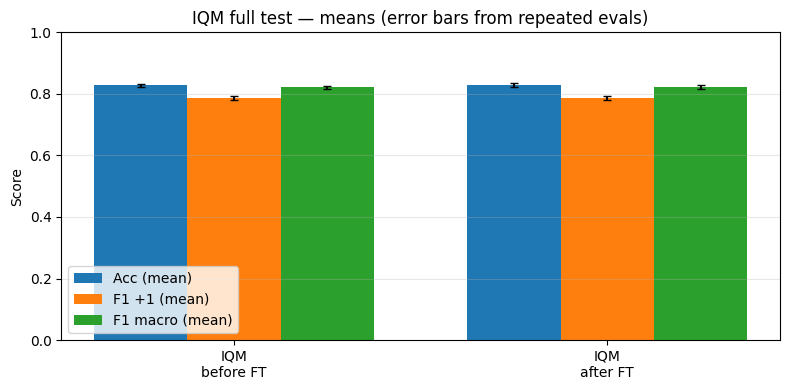

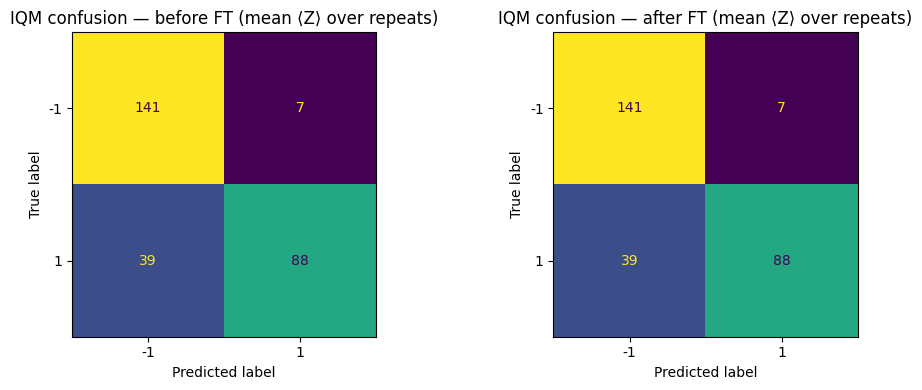

In [50]:
metrics_iqm_after = evaluate_iqm_repeated(
    weights_after,
    X_test,
    y_test,
    "Phase D — IQM test AFTER fine-tune",
    n_repeats=IQM_TEST_REPEATS,
)

metrics_sv_after_exact = metrics_from_preds(predict_raw_sv(weights_after, X_test), y_test)

rows = [
    {
        "stage": "IQM test @ weights after Phase A (SV-only train)",
        "loss": metrics_iqm_before["loss_mean"],
        "loss_std": metrics_iqm_before["loss_std"],
        "acc": metrics_iqm_before["acc_mean"],
        "acc_std": metrics_iqm_before["acc_std"],
        "f1": metrics_iqm_before["f1_mean"],
        "f1_std": metrics_iqm_before["f1_std"],
        "f1_macro": metrics_iqm_before["f1_macro_mean"],
        "f1_macro_std": metrics_iqm_before["f1_macro_std"],
        "note": metrics_iqm_before.get("note", ""),
    },
    {
        "stage": "IQM test @ weights after Phase C (IQM fine-tune)",
        "loss": metrics_iqm_after["loss_mean"],
        "loss_std": metrics_iqm_after["loss_std"],
        "acc": metrics_iqm_after["acc_mean"],
        "acc_std": metrics_iqm_after["acc_std"],
        "f1": metrics_iqm_after["f1_mean"],
        "f1_std": metrics_iqm_after["f1_std"],
        "f1_macro": metrics_iqm_after["f1_macro_mean"],
        "f1_macro_std": metrics_iqm_after["f1_macro_std"],
        "note": metrics_iqm_after.get("note", ""),
    },
    {
        "stage": "Exact statevector test (final weights)",
        "loss": metrics_sv_after_exact["loss"],
        "loss_std": 0.0,
        "acc": metrics_sv_after_exact["acc"],
        "acc_std": 0.0,
        "f1": metrics_sv_after_exact["f1"],
        "f1_std": 0.0,
        "f1_macro": metrics_sv_after_exact["f1_macro"],
        "f1_macro_std": 0.0,
        "note": "StatevectorEstimator",
    },
]
df = pd.DataFrame(rows)
print(df.to_string(index=False))

delta_acc = metrics_iqm_after["acc_mean"] - metrics_iqm_before["acc_mean"]
delta_f1 = metrics_iqm_after["f1_mean"] - metrics_iqm_before["f1_mean"]
delta_fm = metrics_iqm_after["f1_macro_mean"] - metrics_iqm_before["f1_macro_mean"]
print(f"Δ IQM test acc (mean, after - before): {delta_acc:+.4f}")
print(f"Δ IQM test F1 (mean, after - before): {delta_f1:+.4f}")
print(f"Δ IQM test F1_macro (mean, after - before): {delta_fm:+.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
stages = ["IQM\nbefore FT", "IQM\nafter FT"]
x = np.arange(len(stages))
w = 0.25
ax.bar(x - w, [metrics_iqm_before["acc_mean"], metrics_iqm_after["acc_mean"]], w, label="Acc (mean)")
ax.bar(x, [metrics_iqm_before["f1_mean"], metrics_iqm_after["f1_mean"]], w, label="F1 +1 (mean)")
ax.bar(x + w, [metrics_iqm_before["f1_macro_mean"], metrics_iqm_after["f1_macro_mean"]], w, label="F1 macro (mean)")
ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("IQM full test — means (error bars from repeated evals)")
# error bars
ax.errorbar(
    x - w,
    [metrics_iqm_before["acc_mean"], metrics_iqm_after["acc_mean"]],
    yerr=[metrics_iqm_before["acc_std"], metrics_iqm_after["acc_std"]],
    fmt="none",
    ecolor="k",
    capsize=3,
)
ax.errorbar(
    x,
    [metrics_iqm_before["f1_mean"], metrics_iqm_after["f1_mean"]],
    yerr=[metrics_iqm_before["f1_std"], metrics_iqm_after["f1_std"]],
    fmt="none",
    ecolor="k",
    capsize=3,
)
ax.errorbar(
    x + w,
    [metrics_iqm_before["f1_macro_mean"], metrics_iqm_after["f1_macro_mean"]],
    yerr=[metrics_iqm_before["f1_macro_std"], metrics_iqm_after["f1_macro_std"]],
    fmt="none",
    ecolor="k",
    capsize=3,
)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig2, axes = plt.subplots(1, 2, figsize=(10, 4))
cm_b = confusion_matrix(y_test, metrics_iqm_before["cls_pred"], labels=[-1, 1])
cm_a = confusion_matrix(y_test, metrics_iqm_after["cls_pred"], labels=[-1, 1])
ConfusionMatrixDisplay(cm_b, display_labels=[-1, 1]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("IQM confusion — before FT (mean ⟨Z⟩ over repeats)")
ConfusionMatrixDisplay(cm_a, display_labels=[-1, 1]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("IQM confusion — after FT (mean ⟨Z⟩ over repeats)")
plt.tight_layout()
plt.show()

